In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [ ]:
# Make sure file is inside Google Drive
file_path = '/content/drive/MyDrive/student-mat.csv'

stud = pd.read_csv(file_path)

print("Total Students:", len(stud))
stud.head()

Total Students: 395


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
pd.set_option('display.max_columns', None)

stud.info()
stud.describe()
stud.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


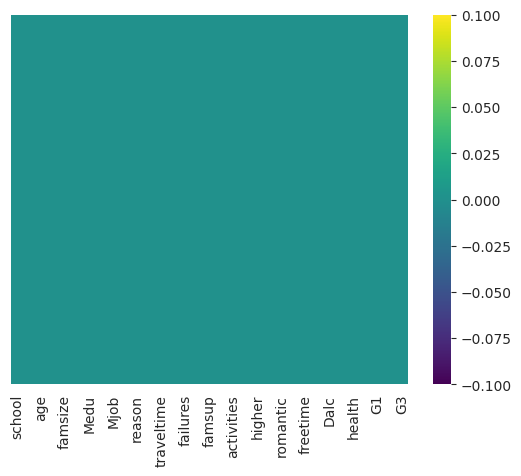

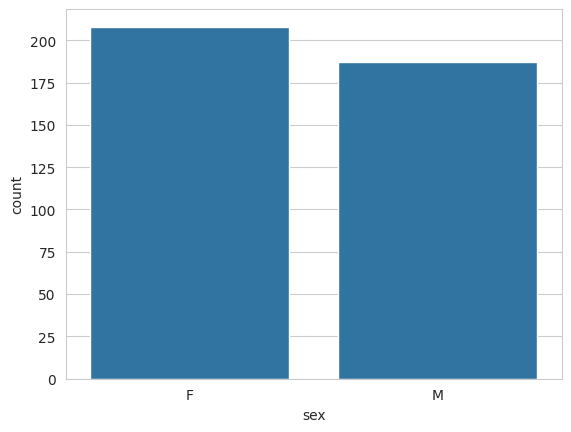

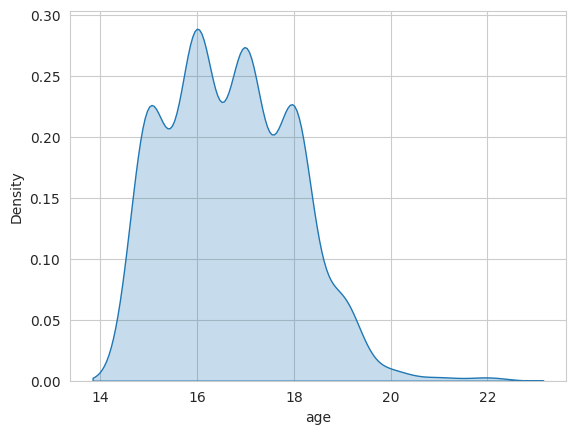

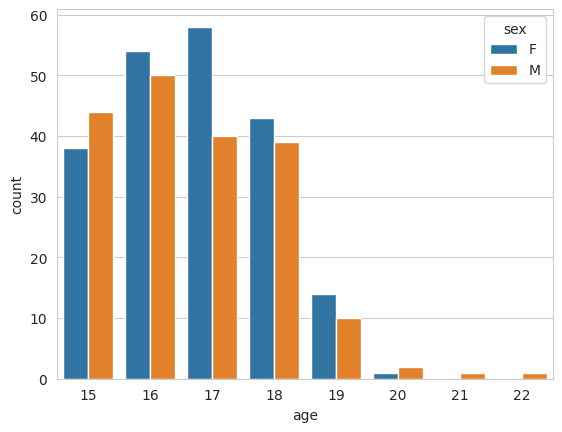

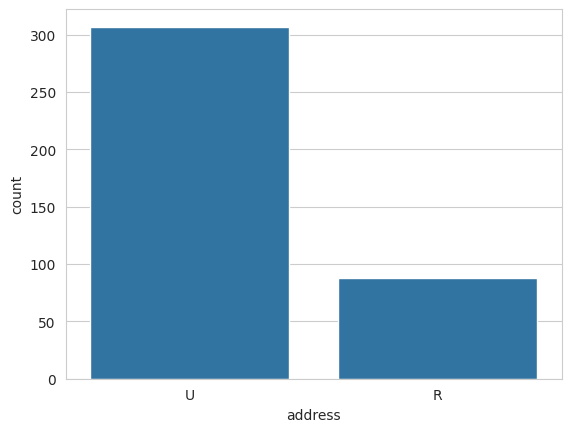

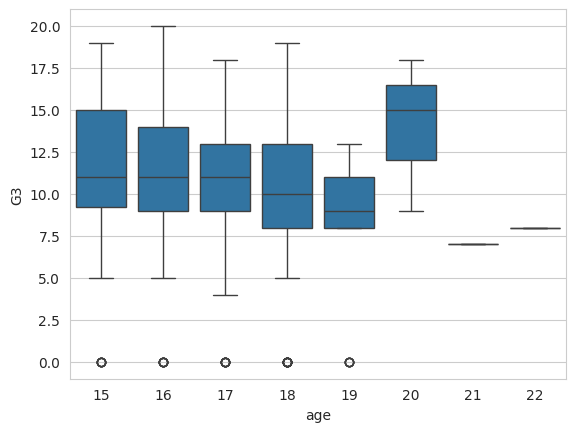

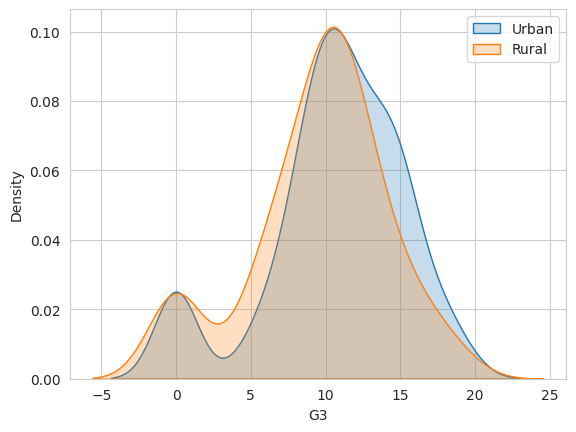

In [ ]:
# Missing values
sns.heatmap(stud.isnull(), cmap="viridis", yticklabels=False)
plt.show()

# Gender
sns.countplot(x='sex', data=stud)
plt.show()

# Age distribution
sns.kdeplot(data=stud, x='age', fill=True)
plt.show()

# Age vs Gender
sns.countplot(x='age', hue='sex', data=stud)
plt.show()

# Address
sns.countplot(x='address', data=stud)
plt.show()

# Age vs Grade
sns.boxplot(x='age', y='G3', data=stud)
plt.show()

# Urban vs Rural Grades
sns.kdeplot(stud[stud['address']=='U']['G3'], label='Urban', fill=True)
sns.kdeplot(stud[stud['address']=='R']['G3'], label='Rural', fill=True)
plt.legend()
plt.show()

In [ ]:
numeric = stud.select_dtypes(include=np.number)
print(numeric.corr()['G3'].sort_values())

failures     -0.360415
age          -0.161579
goout        -0.132791
traveltime   -0.117142
health       -0.061335
Dalc         -0.054660
Walc         -0.051939
freetime      0.011307
absences      0.034247
famrel        0.051363
studytime     0.097820
Fedu          0.152457
Medu          0.217147
G1            0.801468
G2            0.904868
G3            1.000000
Name: G3, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in stud.select_dtypes(include='object').columns:
    stud[col] = le.fit_transform(stud[col])

In [ ]:
stud = stud.drop(['school', 'G1', 'G2'], axis=1, errors='ignore')

top_features = stud.corr().abs()['G3'].sort_values(ascending=False)[:9]
stud = stud[top_features.index]

print(stud.head())

   G3  failures  Medu  higher  age  Fedu  goout  romantic  reason
0   6         0     4       1   18     4      4         0       0
1   6         0     1       1   17     1      3         0       0
2  10         3     1       1   15     1      2         0       2
3  15         0     4       1   15     2      2         1       1
4  10         0     3       1   16     3      2         0       1


In [ ]:
from sklearn.model_selection import train_test_split

X = stud.drop('G3', axis=1)
y = stud['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
baseline = np.median(y_train)
baseline_preds = [baseline] * len(y_test)

mae = np.mean(abs(baseline_preds - y_test))
rmse = np.sqrt(np.mean((baseline_preds - y_test)**2))

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 3.088607594936709
Baseline RMSE: 4.497538004427069


In [ ]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

def evaluate_models():
    models = {
        "Linear": LinearRegression(),
        "Elastic": ElasticNet(),
        "RandomForest": RandomForestRegressor(),
        "ExtraTrees": ExtraTreesRegressor(),
        "SVM": SVR(),
        "GradientBoost": GradientBoostingRegressor()
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = np.mean(abs(pred - y_test))
        rmse = np.sqrt(np.mean((pred - y_test)**2))

        results.append([name, mae, rmse])

    return pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE'])

results = evaluate_models()
print(results)

           Model       MAE      RMSE
0         Linear  2.963019  4.076777
1        Elastic  2.984288  4.227927
2   RandomForest  3.102234  4.357549
3     ExtraTrees  3.632722  4.956423
4            SVM  2.975188  4.233649
5  GradientBoost  3.072038  4.232385


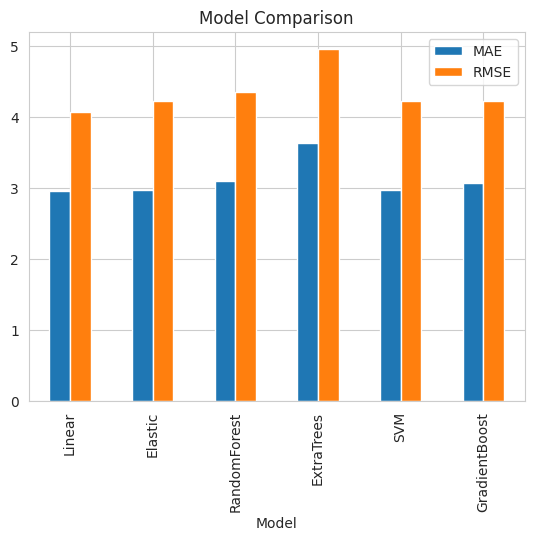

In [ ]:
results.set_index('Model')[['MAE','RMSE']].plot(kind='bar')
plt.title("Model Comparison")
plt.show()

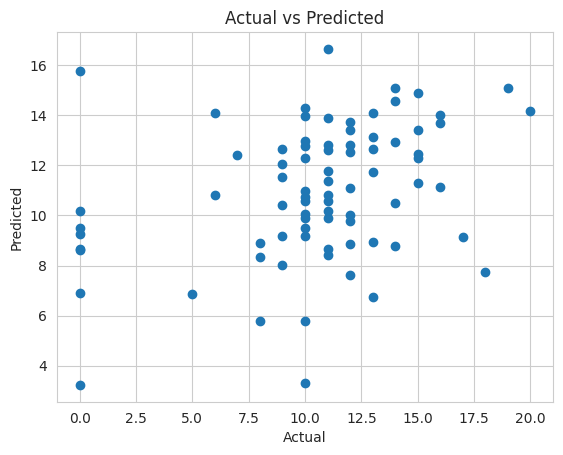

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()